<h1>Recorrido de Grafos</h1>

Dado un grafo ponderado $(G , w )$ donde $G = (V , E )$ y $w : E  \mapsto \mathbb R$, un
arbol de expansión mı́nima es un arbol de expansión en el que la suma
de los pesos w de las aristas es mı́nima.

<h2>Algoritmo Prim</h2>

El algoritmo de Prim construye un arbol visitando vértices de
manera iterativa hasta que se obtiene un árbol de expansión mı́nima.Se comienza desde un vértice cualquiera y en cada iteración se agrega la arista que tenga el mı́nimo peso y no complete un ciclo.
La complejidad computacional del algoritmo de Prim es $O(V \operatorname{log} V)$.
El siguiente pseudo-código implementa el algoritmo mediante una cola de prioridad:


<img src="https://github.com/sherna90/matematicas_discretas/blob/master/images/algoritmo_prim.png?raw=1" />

<h2>Algoritmo Kruskal</h2>

El algoritmo de Kruskal construye un arbol visitando aristas de
manera iterativa hasta que se obtiene un árbol de expansión mı́nima.
Se comienza desde un vértice cualquiera y en cada iteración se
agrega la arista que tenga el mı́nimo peso y no complete un ciclo.
La complejidad computacional del algoritmo de Kruskal es $O(E \operatorname{log} E)$.


<img src="https://github.com/sherna90/matematicas_discretas/blob/master/images/algoritmo_kruskal.png?raw=1" />

In [1]:
import networkx as nx

G = nx.Graph()  # or DiGraph, MultiGraph, MultiDiGraph, etc
E={(1,2):1,(3,4):2,(2,4):1}
G.add_weighted_edges_from([ (u,v,w) for (u,v),w in E.items()])


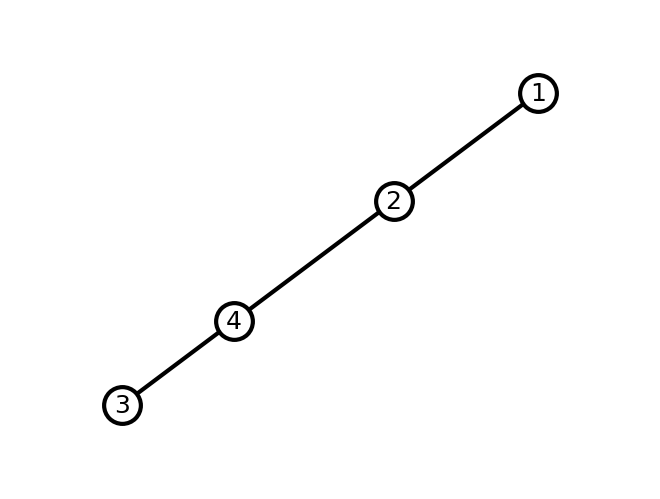

In [2]:
import matplotlib.pyplot as plt

options = {
    "font_size": 18,
    "node_size": 700,
    "node_color": "white",
    "edgecolors": "black",
    "linewidths": 3,
    "width": 3,
    'with_labels':True
}
nx.draw(G,**options)
ax = plt.gca()
ax.margins(0.20)
plt.axis("off")
plt.show()

In [3]:
nx.is_tree(G)  # Check if the graph is connected

True

In [4]:
T_prim=nx.minimum_spanning_tree(G,algorithm='prim')

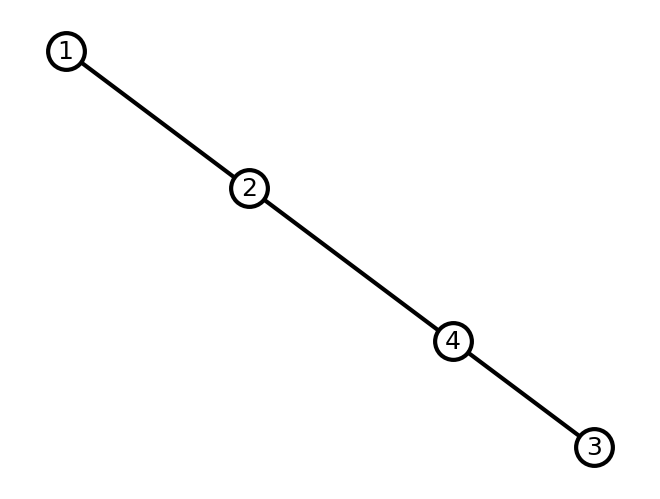

In [5]:
nx.draw(T_prim,**options)

In [6]:
try:
  import google.colab
  IN_COLAB = True
except:
  IN_COLAB = False

In [7]:
IN_COLAB

False

In [8]:
if IN_COLAB:
    !wget 'https://raw.githubusercontent.com/sherna90/matematicas_discretas/master/data/talca_ciclovias.graphml'
    G_talca=nx.read_graphml('talca_ciclovias.graphml')
else:
    G_talca=nx.read_graphml('data/talca_ciclovias.graphml')

In [9]:
print(len(G_talca.nodes))  # Number of nodes in the graph  
print(len(G_talca.edges))  # Number of edges in the graph


7607
20203


In [10]:
nx.is_connected(G_talca.to_undirected())  # Check if the graph is connected

True

In [11]:
for u, v, data in G_talca.edges(data=True):
    if 'length' in data and isinstance(data['length'], str):
        try:
            data['length'] = float(data['length'])
        except ValueError:
            data['length'] = None  # o puedes usar np.nan

In [12]:
T_talca=nx.minimum_spanning_tree(G_talca.to_undirected(),algorithm='kruskal',weight='length')

In [13]:
import geopandas as gpd

nodes=list(T_talca.nodes(data=True))
edges=list(T_talca.edges(data=True))
print('numero de nodos:',len(nodes))
print('numero de aristas:',len(edges))



numero de nodos: 7607
numero de aristas: 7606


In [14]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point

# Suppose nodes is your list of tuples
# nodes = [('688160768', {'y': '-35.4083499', 'x': '-71.6500171', 'osmid': '688160768'}), ...]

# Convert to DataFrame
df_nodes = pd.DataFrame([
    {
        'id': node_id,
        'osmid': data.get('osmid'),
        'x': float(data.get('x')),
        'y': float(data.get('y'))
    }
    for node_id, data in nodes
])

# Create geometry column
df_nodes['geometry'] = df_nodes.apply(lambda row: Point(row['x'], row['y']), axis=1)

# Convert to GeoDataFrame
gdf_nodes = gpd.GeoDataFrame(df_nodes, geometry='geometry', crs="EPSG:4326")

gdf_nodes.head()

,id,osmid,x,y,geometry
0,688160768,688160768,-71.650017,-35.408350,POINT (-71.65002 -35.40835)
1,688160769,688160769,-71.649685,-35.407650,POINT (-71.64968 -35.40765)
2,688160770,688160770,-71.649969,-35.407399,POINT (-71.64997 -35.40740)
3,688160771,688160771,-71.651192,-35.406245,POINT (-71.65119 -35.40625)
4,3225845764,3225845764,-71.687439,-35.444759,POINT (-71.68744 -35.44476)


<Axes: >

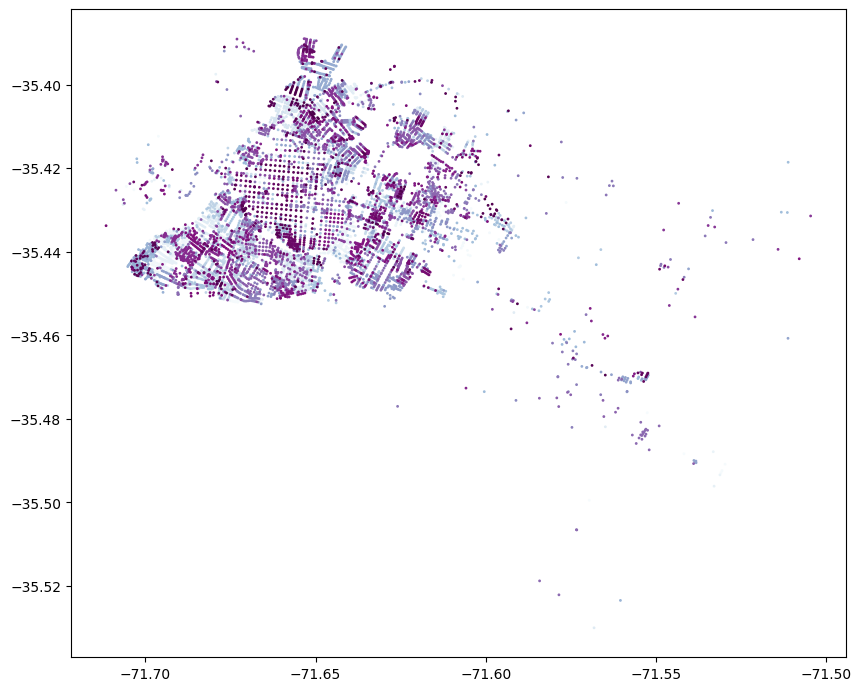

In [15]:
gdf_nodes.plot(cmap='BuPu', markersize=1, figsize=(10, 10))

In [16]:
edges[0]

('688160768',
 '685043965',
 {'length': 37.381,
  'lanes': '2',
  'osmid': '110462466',
  'oneway': 'False',
  'highway': 'residential',
  'name': 'Calle 17 Norte'})

In [17]:
from shapely.geometry import LineString

# Example: edges = [('688160768', '688160765', {...}), ...]
# gdf_nodes must have 'id', 'x', 'y' columns

df_edges = pd.DataFrame([
    {
        'source': u,
        'target': v,
        **data
    }
    for u, v, data in edges
])

def get_point(node_id):
    row = gdf_nodes[gdf_nodes['id'] == node_id].iloc[0]
    return (row['x'], row['y'])

df_edges['geometry'] = df_edges.apply(
    lambda row: LineString([get_point(row['source']), get_point(row['target'])]), axis=1
)

gdf_edges = gpd.GeoDataFrame(df_edges, geometry='geometry', crs="EPSG:4326")

gdf_edges.head()

,source,target,length,lanes,osmid,oneway,highway,name,width,maxspeed,geometry,junction,ref,service,bridge,access,tunnel
0,688160768,685043965,37.381,2,110462466,False,residential,Calle 17 Norte,NaN,NaN,"LINESTRING (-71.65002 -35.40835, -71.65030 -35...",NaN,NaN,NaN,NaN,NaN,NaN
1,688160768,688160765,40.574,2,110462466,False,residential,Calle 17 Norte,NaN,NaN,"LINESTRING (-71.65002 -35.40835, -71.64973 -35...",NaN,NaN,NaN,NaN,NaN,NaN
2,688160769,688160770,37.977,1,54674731,False,living_street,17½ Norte,NaN,NaN,"LINESTRING (-71.64968 -35.40765, -71.64997 -35...",NaN,NaN,NaN,NaN,NaN,NaN
3,688160769,688160766,38.489,1,54674731,False,living_street,17½ Norte,NaN,NaN,"LINESTRING (-71.64968 -35.40765, -71.64940 -35...",NaN,NaN,NaN,NaN,NaN,NaN
4,688160770,688160755,55.606,1,54674731,False,living_street,17½ Norte,NaN,NaN,"LINESTRING (-71.64997 -35.40740, -71.65038 -35...",NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

<Figure size 1000x1000 with 0 Axes>

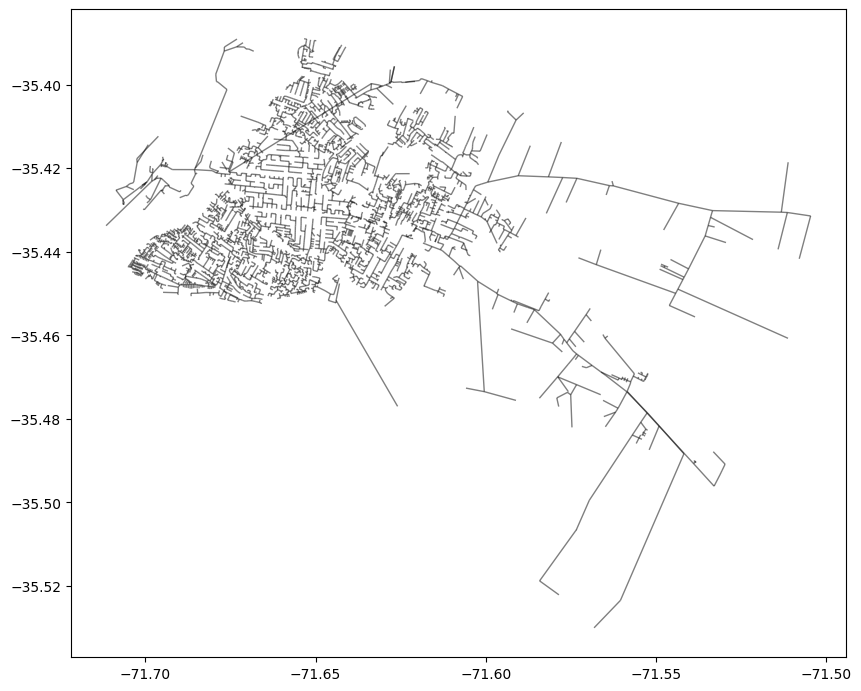

In [19]:
plt.figure(figsize=(10, 10))
gdf_edges.plot( color='black', linewidth=1, alpha=0.5,cmap='BuPu', figsize=(10, 10))

<h2>Ejercicio</h2>

Se desea construir una red que conecte todos los puntos limpios en una ciudad a partir de un puncto y un radio especifico. Para esto, se usará la API del Ministerio del Medio Ambiente MMA.

In [20]:
import pandas as pd

# Cafeteria UCM (-35.434415,-71.620053)
df=pd.read_json('https://puntoslimpios.mma.gob.cl//api/points/geo?lat=-35.434415&lng=-71.620053&distance=1')


In [21]:
df['geometry'] = df.apply(lambda row: Point(row['lng'], row['lat']), axis=1)
gdf_puntoslimpios = gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")
gdf_puntoslimpios.head()

,distance,lat,status,lng,owner,type,address_type,manager,address_number,address_name,region,commune,materials,geometry
0,0.255533,-35.432585,open,-71.618347,Claudia Mocárquer,pv,,Reciclaplast,,35 Oriente,"{'id': 7, 'abbreviation': 'ma', 'name': 'Maule'}","{'id': 116, 'name': 'Talca'}",[plastic],POINT (-71.61835 -35.43259)
1,0.282649,-35.432454,open,-71.618068,Claudia Mocárquer,pv,,Reciclaplast,,35 Oriente,"{'id': 7, 'abbreviation': 'ma', 'name': 'Maule'}","{'id': 116, 'name': 'Talca'}",[plastic],POINT (-71.61807 -35.43245)
2,0.417828,-35.430718,open,-71.619228,guillermo toro,pv,Plaza,cristaleria toro,,34 Oriente,"{'id': 7, 'abbreviation': 'ma', 'name': 'Maule'}","{'id': 116, 'name': 'Talca'}",[glass],POINT (-71.61923 -35.43072)
3,0.420287,-35.432216,open,-71.623826,Claudia Mocárquer,pv,,Reciclaplast,,36 Oriente,"{'id': 7, 'abbreviation': 'ma', 'name': 'Maule'}","{'id': 116, 'name': 'Talca'}",[plastic],POINT (-71.62383 -35.43222)
4,0.513515,-35.432071,open,-71.624937,Municipalidad de talca,pv,Villa,Reciclaje de Plasticos Vergara,,Don Matías - 2 Norte 31 Oriente,"{'id': 7, 'abbreviation': 'ma', 'name': 'Maule'}","{'id': 116, 'name': 'Talca'}",[plastic],POINT (-71.62494 -35.43207)


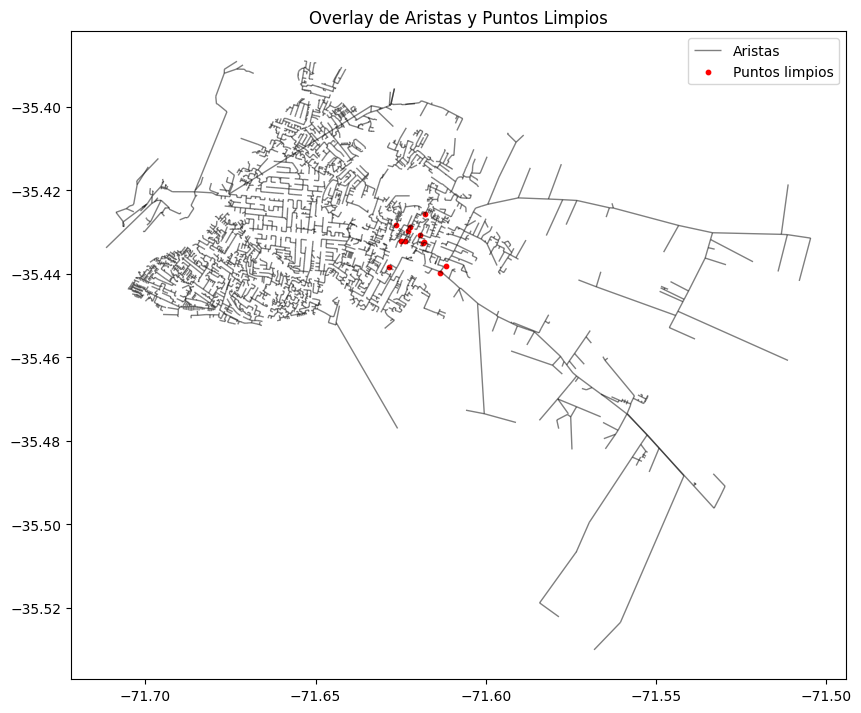

In [22]:
fig, ax = plt.subplots(figsize=(10, 10))

# Dibuja las aristas del grafo (gdf_edges)
gdf_edges.plot(ax=ax, color='black', linewidth=1, alpha=0.5, label='Aristas')

# Dibuja los puntos limpios sobre el mismo eje
gdf_puntoslimpios.plot(ax=ax, color='red', markersize=10, label='Puntos limpios')

# Opcional: dibuja también los nodos si quieres

plt.legend()
plt.title('Overlay de Aristas y Puntos Limpios')
plt.show()

In [23]:
import numpy as np
from math import radians, cos, sin, asin, sqrt

def haversine(lon1, lat1, lon2, lat2):
    lon1, lat1, lon2, lat2 = map(radians, [lon1, lat1, lon2, lat2])
    dlon = lon2 - lon1 
    dlat = lat2 - lat1 
    a = sin(dlat/2)**2 + cos(lat1) * cos(lat2) * sin(dlon/2)**2
    c = 2 * asin(sqrt(a)) 
    r = 6371 # Radius of earth in kilometers. Use 3956 for miles
    return c * r *1000


La distancia de Haversine entre los puntos considera una linea recta entre cada uno de ellos. Si bien es posible crear un grafo completo y luego un arbol de expansión, este grafo no considera el costo real de llegar desde un punto limpio a otro. 

In [24]:
def pairwise_haversine(df):
    """
    Calcula la matriz de distancias Haversine para todos los pares de coordenadas en el DataFrame.
    El DataFrame debe tener columnas 'lat' y 'lng'.
    Retorna un DataFrame con las distancias en metros.
    """
    n = len(df)
    dist_matrix = np.zeros((n, n))
    coords = df[['lat', 'lng']].values
    for i in range(n):
        for j in range(i+1, n):
            d = haversine(coords[i][1], coords[i][0], coords[j][1], coords[j][0])
            dist_matrix[i, j] = d
            dist_matrix[j, i] = d
    return pd.DataFrame(dist_matrix, columns=df.index, index=df.index)

# Ejemplo de uso:
dist_df = pairwise_haversine(gdf_puntoslimpios)
dist_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11
0,0.000000,29.174511,222.417407,498.099200,599.780310,508.044132,543.934099,909.323926,864.221333,863.054236,1125.764473,777.566055
1,29.174511,0.000000,219.790965,522.355463,623.786325,519.933022,549.541472,910.237591,857.263246,876.841022,1154.836300,762.014522
2,222.417407,219.790965,0.000000,448.657721,538.693216,338.874560,340.403442,1129.981124,1071.665999,696.284423,1198.414703,581.891794
3,498.099200,522.355463,448.657721,0.000000,101.924127,283.974056,407.227588,1256.545506,1284.062762,483.362934,806.639189,912.004730
4,599.780310,623.786325,538.693216,101.924127,0.000000,318.115011,440.794626,1343.512952,1379.325162,429.059790,772.603909,962.865842


Calculamos los nodos del grafo mas cercanos a cada punto limpio.

In [26]:
from scipy.spatial import cKDTree

# Extrae las coordenadas de ambos GeoDataFrames
coords_puntos = np.array(list(zip(gdf_puntoslimpios.geometry.y, gdf_puntoslimpios.geometry.x)))
coords_nodos = np.array(list(zip(gdf_nodes.geometry.y, gdf_nodes.geometry.x)))

# Construye el árbol KD para los nodos
tree = cKDTree(coords_nodos)

# Busca el nodo más cercano para cada punto limpio
distancias, indices = tree.query(coords_puntos, k=1)

# Agrega el índice y la distancia del nodo más cercano al GeoDataFrame de puntos limpios
gdf_puntoslimpios['nearest_node_idx'] = indices
gdf_puntoslimpios['nearest_node_dist'] = distancias

# Si quieres también el id del nodo más cercano:
gdf_puntoslimpios['nearest_node_id'] = gdf_nodes.iloc[indices]['id'].values

gdf_puntoslimpios[['lat', 'lng', 'nearest_node_id', 'nearest_node_dist']].head()

,lat,lng,nearest_node_id,nearest_node_dist
0,-35.432585,-71.618347,1264104197,0.000157
1,-35.432454,-71.618068,1264104484,0.000068
2,-35.430718,-71.619228,688189739,0.000116
3,-35.432216,-71.623826,2049946603,0.000209
4,-35.432071,-71.624937,2049946567,0.000504


In [27]:
nx.shortest_path(G_talca, source='1264104197', target='1264104484')

['1264104197', '1264104484']

In [29]:
nx.shortest_path_length(G_talca, source='1264104197', target='1264104484',weight='length')

39.837

In [64]:
#Calcula las distancias más cortas desde cada nodo en 'nearest_node_id' a todos los demás nodos del grafo

# Lista de nodos de inicio (sin duplicados)
start_nodes = gdf_puntoslimpios['nearest_node_id'].unique()

# Diccionario para guardar los resultados
shortest_paths = {}
shortest_lengths = {}

for node in start_nodes:
    # Calcula la distancia más corta desde 'node' a todos los demás nodos usando el peso 'length'
    lengths = nx.single_source_dijkstra_path_length(G_talca, node, weight='length')
    shortest_lengths[node] = lengths
    # Si también quieres los caminos:
    # paths = nx.single_source_dijkstra_path(G_talca, node, weight='length')
    # shortest_paths[node] = paths

# Ejemplo: distancia desde el primer nodo a todos los demás
first_node = start_nodes[0]
final_node = start_nodes[1]
print(f"Distancias desde {first_node} a {final_node}:")
print(shortest_lengths[first_node][final_node])  # Muestra las primeras 10 distancias

Distancias desde 1264104197 a 1264104484:
39.837


In [34]:
G_completo = nx.Graph()

# Usa el DataFrame dist_df generado previamente con pairwise_haversine
for i in shortest_lengths.keys():
    for j in shortest_lengths.keys():
        if i != j:
            G_completo.add_edge(i, j, weight=shortest_lengths[i][j])
            
print(f"Número de nodos: {G_completo.number_of_nodes()}")
print(f"Número de aristas: {G_completo.number_of_edges()}")

Número de nodos: 12
Número de aristas: 66


In [38]:
T_puntoslimpios = nx.minimum_spanning_tree(G_completo, algorithm='kruskal', weight='weight')

In [39]:
print(f"Número de nodos: {T_puntoslimpios.number_of_nodes()}")
print(f"Número de aristas: {T_puntoslimpios.number_of_edges()}")

Número de nodos: 12
Número de aristas: 11


In [41]:
rutas_mas_cortas=[nx.shortest_path(G_talca, source=u, target=v,weight='length') for u,v,d in list(T_puntoslimpios.edges(data=True))]

In [ ]:
# rutas_mas_cortas es una lista de listas de ids de nodos
# gdf_nodes debe tener columnas 'id', 'x', 'y'

def get_point_coords(node_id):
    row = gdf_nodes[gdf_nodes['id'] == node_id].iloc[0]
    return (row['x'], row['y'])

# Construye un GeoDataFrame con las rutas como LineString
df_rutas = []
for ruta in rutas_mas_cortas:
    coords = [get_point_coords(nodo) for nodo in ruta]
    df_rutas.append({'ruta': ruta, 'geometry': LineString(coords)})

gdf_rutas = gpd.GeoDataFrame(df_rutas, geometry='geometry', crs="EPSG:4326")
gdf_rutas.head()

,ruta,geometry
0,"[1264104197, 1264104484]","LINESTRING (-71.61832 -35.43274, -71.61812 -35..."
1,"[1264104197, 1264104099, 3956745368, 126410394...","LINESTRING (-71.61832 -35.43274, -71.61710 -35..."
2,"[1264104484, 688189706, 688189708, 688189710, ...","LINESTRING (-71.61812 -35.43242, -71.61779 -35..."
3,"[688189739, 688189737, 688189742, 4408434786, ...","LINESTRING (-71.61912 -35.43075, -71.61874 -35..."
4,"[2049946603, 2049946567]","LINESTRING (-71.62399 -35.43208, -71.62528 -35..."


In [56]:
gdf_rutas.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

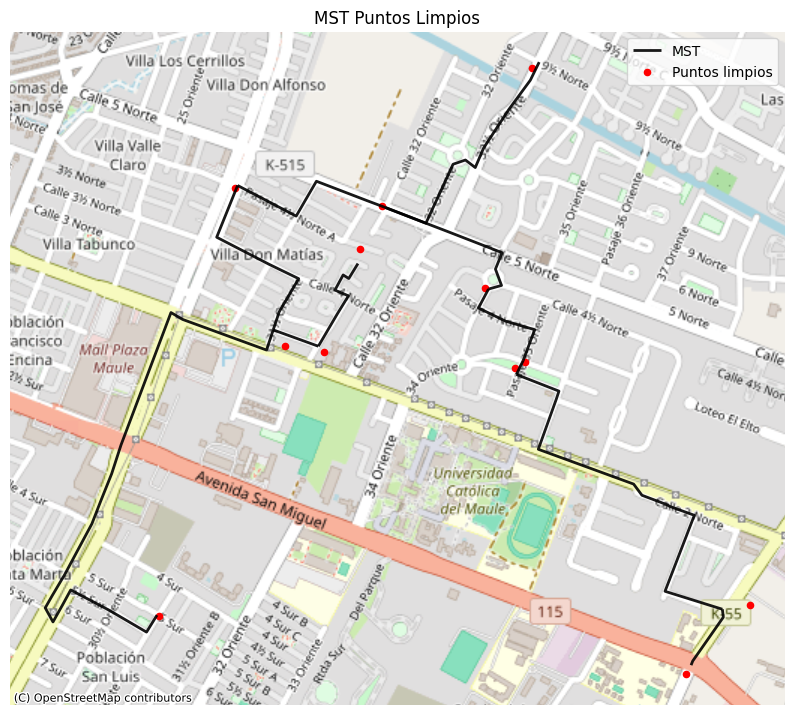

In [59]:
import contextily as ctx

fig, ax = plt.subplots(figsize=(10, 10))

# Dibuja las rutas del MST
gdf_rutas.to_crs(epsg=3857).plot(ax=ax, color='black', linewidth=2, alpha=0.9, label='MST')

# Dibuja los puntos limpios
gdf_puntoslimpios.to_crs(epsg=3857).plot(ax=ax, color='red', markersize=20, label='Puntos limpios')

# Agrega el fondo de OpenStreetMap
ctx.add_basemap(ax, source=ctx.providers.OpenStreetMap.Mapnik)

ax.set_axis_off()
plt.legend()
plt.title('MST Puntos Limpios')
plt.show()